In [1]:
import os

def get_matching_files(directory, pattern):
    """
    Returns a list of file paths in 'directory' whose names contain 'pattern'.
    """
    return [
        os.path.join(directory, fname)
        for fname in os.listdir(directory)
        if pattern in fname
    ]

In [2]:
# fetch log files for evaluation
import re
import polars as pl

# use a looser matcher so files like:
#  - dt_rtg03_test_episode_02_logs.parquet
#  - dt_test_episode_02_rtg03_logs.parquet
# are both returned
matching_files = get_matching_files("../data", "test_episode_02")

# capture algorithm at start, trailing _logs (allow optional .parquet)
pat = re.compile(r"^(?P<algo>[A-Za-z0-9]+).*?_logs(?:\.parquet)?$", re.IGNORECASE)
# find _rtgNN anywhere in the name
rtg_search_re = re.compile(r"_rtg(?P<rtg>\d+)", re.IGNORECASE)

test_logs: dict[str, pl.DataFrame] = {}
skipped = []

for file_path in matching_files:
    fname = os.path.basename(file_path)
    m = pat.match(fname)
    if not m:
        print(f"Skipping unrecognized filename: {fname}")
        skipped.append(fname)
        continue

    algo = m.group("algo")
    rtg_m = rtg_search_re.search(fname)
    rtg = rtg_m.group("rtg") if rtg_m else None
    label = f"{algo}_rtg{rtg}" if rtg else algo

    # try to read parquet; if unreadable or empty, register empty DF so label exists
    try:
        if os.path.getsize(file_path) == 0:
            df = pl.DataFrame()
            print(f"Warning: zero-byte file -> empty DF for {label}: {fname}")
        else:
            df = pl.read_parquet(file_path)
    except Exception as e:
        print(f"Failed to read {fname}: {e} -> registering empty DF for {label}")
        df = pl.DataFrame()

    # ensure episode_id exists for non-empty frames
    if not df.is_empty() and "episode_id" not in df.columns:
        df = df.with_columns(pl.lit(0).alias("episode_id"))

    test_logs[label] = df
    print(f"Registered: {fname} -> label='{label}', rows={len(df)}")

print("Final labels:", list(test_logs.keys()))
print("Skipped files:", skipped)

Registered: sdp_test_episode_02_logs.parquet -> label='sdp', rows=905307
Registered: ddpg_test_episode_02_logs.parquet -> label='ddpg', rows=904730
Registered: sac_test_episode_02_logs.parquet -> label='sac', rows=750608
Registered: td3_test_episode_02_logs.parquet -> label='td3', rows=904730
Registered: mrdp_test_episode_02_logs.parquet -> label='mrdp', rows=905307
Registered: a2c_test_episode_02_logs.parquet -> label='a2c', rows=781521
Registered: ppo_test_episode_02_logs.parquet -> label='ppo', rows=679425
Registered: rule_test_episode_02_logs.parquet -> label='rule', rows=873851
Final labels: ['sdp', 'ddpg', 'sac', 'td3', 'mrdp', 'a2c', 'ppo', 'rule']
Skipped files: []


In [4]:
# Split into a list of DataFrames, one per episode

all_logs = {
    label: [df.filter(pl.col("episode_id") == eid) for eid in df["episode_id"].unique()]
    for label, df in test_logs.items()
}

In [6]:
from helper import find_problematic_episodes
"""
all_logs: dict[str, list[pl.DataFrame]]
    Mapping from algorithm/label → list of Polars DataFrames (one DataFrame per episode). Each DataFrame is expected to contain columns like reward, rtg, timestep, state_*, action_* and episode_id already split.
reward_thresh: float
    Threshold for maximum absolute reward to flag (default 1e5).
rtg_thresh: float | None
    Threshold for maximum absolute rtg to flag. If None the function will not flag rtg magnitude issues (but rtg values are still used to compute suggested_return_scale).
state_thresh: float
    Threshold for maximum absolute value across state_* columns to flag (default 1e3).
action_thresh: float
    Threshold for maximum absolute value across action_* columns to flag (default 1e3).
max_timestep: int | None
    If set, flags episodes where timestep/time/step maximum exceeds this value.
rtg_percentile_for_scale: int
    Percentile of per-episode median(|rtg|) used to compute suggested_return_scale (default 90).
target_90th_after_scaling: float
    Desired value for that percentile after scaling (default 10.0). The suggested scale = percentile_value / target_90th_after_scaling (bounded ≥ 1.0).

This function returns a tuple: (reports, suggested_return_scale).
reports is a list of dicts; each dict has:
    algorithm: str — algorithm / file label containing the episode.
    episode_index: int — index of the episode within all_logs[algorithm].
    rows: int — number of rows in that episode DataFrame (0 if empty).
    issues: list[str] — concise problem tags / messages. Typical entries:
        "empty_episode" — episode dataframe is empty.
        "{col}: NaN=X,+Inf=Y,-Inf=Z" — column contains NaN/Inf counts.
        "reward_mag>{reward_thresh}" — reward absolute max exceeded threshold.
        "rtg_mag>{rtg_thresh}" — rtg absolute max exceeded threshold (if rtg_thresh provided).
        "state_mag>{state_thresh}" — any state_* column exceeded threshold.
        "action_mag>{action_thresh}" — any action_* column exceeded threshold.
        "{tcol}_>{max_timestep}" — timestep/time/step column exceeded allowed max.

The suggested_return_scale is a float computed from the distribution of episode median |rtg| values.
    
"""
problems, suggested_scale = find_problematic_episodes(
    all_logs,
    reward_thresh=1e5,
    state_thresh=1e3,
    max_timestep=20000
)


Problematic episodes by algorithm:
  sac: 1 episodes
  rule: 2 episodes
First 20 problem rows:
algorithm  episode_index  rows                issues
      sac             30 17566 [reward_mag>100000.0]
     rule              7 17566 [reward_mag>100000.0]
     rule             53 17566 [reward_mag>100000.0]

Suggested return_scale (to bring ~90th pct episode-median |rtg| to ~10.0): 1


In [8]:
# pick one problematic episode
algo, ep = "rule", 7
df = all_logs[algo][ep]

# where is reward huge?
mx = df.select(pl.col("reward").abs().max()).item()
print("max |reward|:", mx)

# count how many steps exceed threshold
th = 1e5
print("count |reward|>1e5:", df.filter(pl.col("reward").abs() > th).height)

# show the rows with huge reward (and a few neighboring rows)
bad = df.with_row_index("i").filter(pl.col("reward").abs() > th)
display(bad.head(20))

# look at context around the first spike
if bad.height > 0:
    i0 = bad["i"][0]
    display(df.with_row_index("i").filter(pl.col("i").is_between(i0-5, i0+5)))

max |reward|: 146776.72646161672
count |reward|>1e5: 2


i,step,norm_observation,raw_observation,action,reward,info,episode_id
u32,i64,list[f64],list[f64],list[f32],f64,struct[14],i32
3941,3941,"[0.5, 0.866025, … 1.0]","[0.5, 0.866025, … 0.0]",[0.00013],106483.541493,"{0.000214,6.990567,1.102214,0.15,0.165332,-0.165332,-21.296741,-73.265857,-1.0,-0.483807,0,0.290678,-106483.706825,false}",7
5471,5471,"[-0.258819, 0.965926, … 1.0]","[-0.258819, 0.965926, … 0.0]",[-0.000431],-146776.726462,"{-0.000712,6.999288,0.239288,0.15,0.035893,-0.035893,29.355338,32.24038,-1.0,57.523648,0,0.910515,146776.690568,false}",7


i,step,norm_observation,raw_observation,action,reward,info,episode_id
u32,i64,list[f64],list[f64],list[f32],f64,struct[14],i32
3936,3936,"[0.0, 1.0, … 1.0]","[0.0, 1.0, … 0.0]",[-0.000934],-37.216095,"{-0.001541,6.317384,0.122459,0.15,0.018369,-0.018369,0.00744,0.025594,-1.0,72.650518,0,0.290678,37.197726,false}",7
3937,3937,"[0.0, 1.0, … 1.0]","[0.0, 1.0, … 0.0]",[-0.003678],-32.462884,"{-0.006069,6.311316,0.115931,0.15,0.01739,-0.01739,0.006489,0.022324,-1.0,72.672842,0,0.290678,32.445494,false}",7
3938,3938,"[0.258819, 0.965926, … 1.0]","[0.258819, 0.965926, … 0.0]",[-0.007585],-27.547732,"{-0.012515,6.298801,1.307485,0.15,0.196123,-0.196123,0.00547,0.018819,-1.0,72.691661,0,0.290678,27.351609,false}",7
3939,3939,"[0.258819, 0.965926, … 1.0]","[0.258819, 0.965926, … 0.0]",[0.580601],-2.453328,"{0.701199,7.0,3.293199,0.15,0.49398,-0.49398,0.000392,0.001348,-1.0,72.693009,0,0.290678,1.959348,false}",7
3940,3940,"[0.5, 0.866025, … 0.39187]","[0.5, 0.866025, … 0.0]",[-0.005847],-129.800083,"{-0.009648,6.990352,2.604352,0.15,0.390653,-0.390653,0.025882,0.08904,-1.0,72.782049,0,0.290678,129.40943,false}",7
…,…,…,…,…,…,…,…
3942,3942,"[0.707107, 0.707107, … 0.0]","[0.707107, 0.707107, … 0.0]",[0.001583],-513.477511,"{0.002613,6.993179,0.121613,0.15,0.018242,-0.018242,0.102692,0.353284,-1.0,-0.130523,0,0.290678,513.45927,false}",7
3943,3943,"[0.707107, 0.707107, … 1.0]","[0.707107, 0.707107, … 0.0]",[-0.003396],-220.920771,"{-0.005603,6.987576,0.103397,0.15,0.01551,-0.01551,0.044181,0.151993,-1.0,0.02147,0,0.290678,220.905261,false}",7
3944,3944,"[0.866025, 0.5, … 1.0]","[0.866025, 0.5, … 0.0]",[-0.028832],-24.424778,"{-0.047574,6.940003,0.061426,0.15,0.009214,-0.009214,0.004883,0.016799,-1.0,0.03827,0,0.290678,24.415564,false}",7


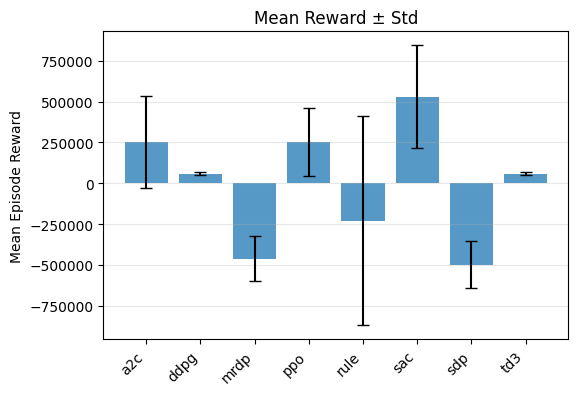

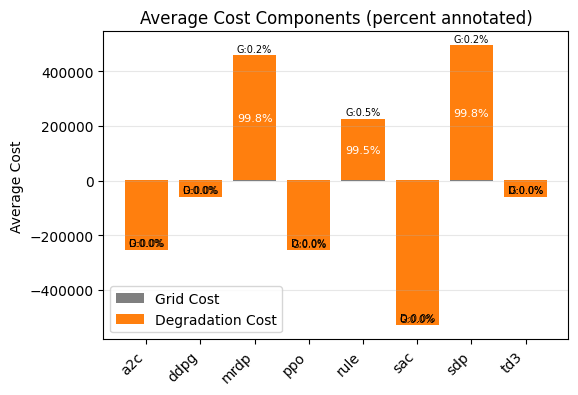

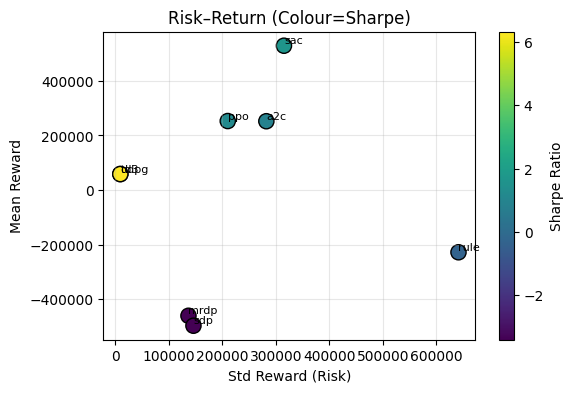

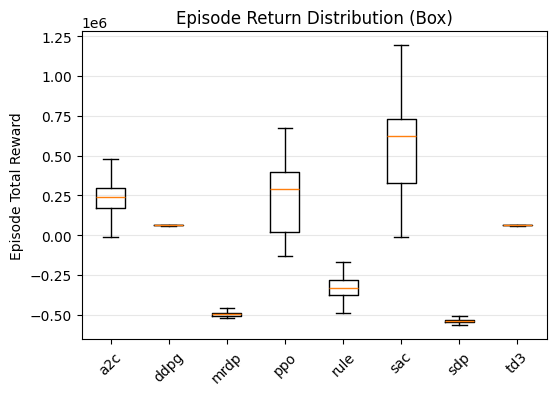

Saved evaluation metrics to: ../eval_output/evaluation_metrics.csv


In [4]:
from pathlib import Path
from helper import evaluate_experiments

base_save_dir = "../eval_output"


# evaluate experiments outcomes
metrics = evaluate_experiments(all_logs, target_return=0.0, save_dir=str(base_save_dir))

# log metrics as csv
metrics_csv_path = Path(base_save_dir) / "evaluation_metrics.csv"
metrics.write_csv(str(metrics_csv_path))
print(f"Saved evaluation metrics to: {metrics_csv_path}")



In [5]:
# 1. If you want the best RTG across ALL experiments/datasets provided:
best_overall_rtg = metrics["recommended_rtg"].max()
print(f"Best RTG to use: {best_overall_rtg}")

# 2. If you only want the RTG for a specific dataset (e.g. 'SAC_training_data'):
# Filter for that specific experiment name
specific_rtg = metrics.filter(pl.col("experiment") == "rule")["recommended_rtg"][0]
print(f"RTG for SAC data: {specific_rtg}")

Best RTG to use: 4545141.85176429
RTG for SAC data: 4545141.85176429


In [4]:
for algo, logs in all_logs.items():
    print(f"{algo}: {len(logs)} episodes")

sdp: 60 episodes
ddpg: 60 episodes
dt_rtg100: 60 episodes
sac: 60 episodes
dt_rtg03: 60 episodes
td3: 60 episodes
mrdp: 60 episodes
dt_rtg10: 60 episodes
a2c: 240 episodes
ppo: 60 episodes
rule: 60 episodes
dt_rtg30: 60 episodes


In [7]:
from typing import Any
from helper import AlgorithmActionComparator, ActionComparisonConfig
def compare_action_pairwise_to_reference(
    logs_dict: dict[str, list[pl.DataFrame]],
    reference: str,
    base_save_dir: str | Path | None = None,
    **kwargs: Any,
 ) -> dict[str, Any]:
    """
    Run pairwise comparisons of each algorithm vs a reference algorithm.
    
    kwargs are forwarded to ActionComparisonConfig (e.g., bins, time_periods, etc.).
    Returns a dict: algo_name -> ActionComparisonResult or metrics dict.
    """
    comparator = AlgorithmActionComparator(action_logs=logs_dict)
    results: dict[str, Any] = {}
    for algo in logs_dict:
        if algo == reference:
            continue
        sub_logs = {reference: logs_dict[reference], algo: logs_dict[algo]}
        # If a base_save_dir is provided, create a per-pair subdirectory so output files don't overwrite each other
        if base_save_dir:
            out_dir = Path(base_save_dir) / f"{reference}_vs_{algo}"
            out_dir.mkdir(parents=True, exist_ok=True)
            kwargs_copy = dict(kwargs)
            # ensure we set save_dir to output dir
            kwargs_copy["save_dir"] = str(out_dir)
        else:
            kwargs_copy = kwargs
        cfg = ActionComparisonConfig(reference=reference, **kwargs_copy)
        result = comparator.compare(logs_dict=sub_logs, config=cfg)
        results[algo] = result
    return results


In [6]:
steps_per_hour = int(1 / 0.5)  # number of steps per hour given a 30-min step duration (2)

def time_to_step(hour: int, minute: int = 0, second: int = 0, steps_per_hour_: int | None = None) -> int:
    """
    Convert a time-of-day (hour, minute, second) into a 0-indexed step mark for that day,
    using steps_per_hour (defaults to `steps_per_hour` defined above).
    Returns the floor of the step (i.e., which step interval that timestamp falls into).
    """
    sp = steps_per_hour_ or steps_per_hour
    total_seconds = hour * 3600 + minute * 60 + second
    seconds_per_step = 3600 / sp
    return int(total_seconds // seconds_per_step)

# time periods to compare in steps
# first 2 days, 2 days after 4th week, 2 days after 4th month, 2 days at 11th month (assuming 30-min per step, 48 steps/day)
first_step = 0
fourth_week = 4 * 7 * 48  # 4th week
fourth_month = 4 * 30 * 48  # 4th month
eleventh_month = 11 * 30 * 48  # 11th month
two_day_steps = 2 * 48

# morning period markers
five_am_mark = time_to_step(5, 0)   # 05:00
ten_am_mark = time_to_step(10, 0)   # 10:00

# mid-day marker
three_pm_mark = time_to_step(15, 0)  # 15:00

# evening marker
nine_pm_mark = time_to_step(21, 0)   # 21:00

# pick 52nd episode if exists for all algorithms
episode_52 = {}
for algo, logs in all_logs.items():
    if len(logs) > 52:
        episode_52[algo] = logs[52]

# Wrap single-episode DataFrames into lists expected by the comparator
episode_single = {k: [v] for k, v in episode_52.items()}

# check if we have data for episode 52
if not episode_52:
    print("No data available for episode 52 across the algorithms.")

/code/src/helper.py:1316: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_profile, ax_profile = plt.subplots(figsize=(8, 4))


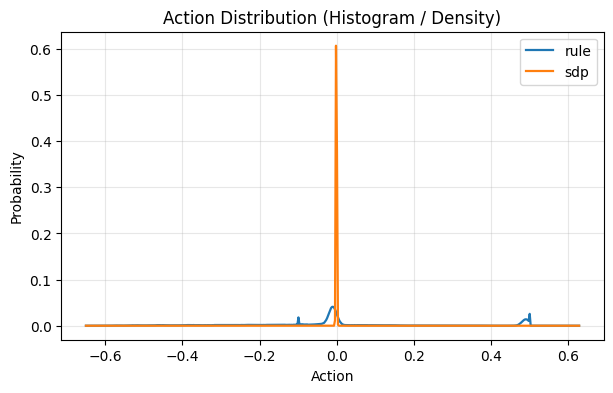

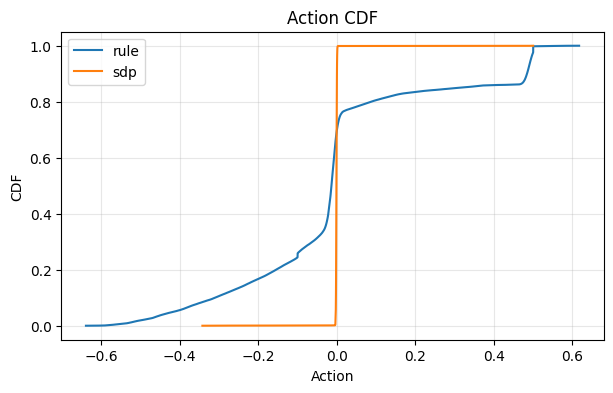

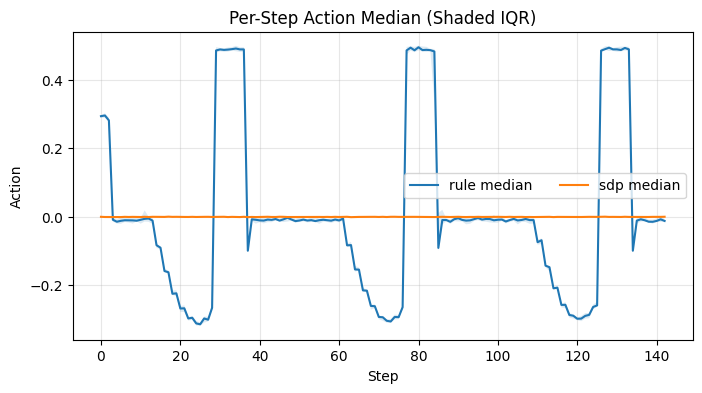

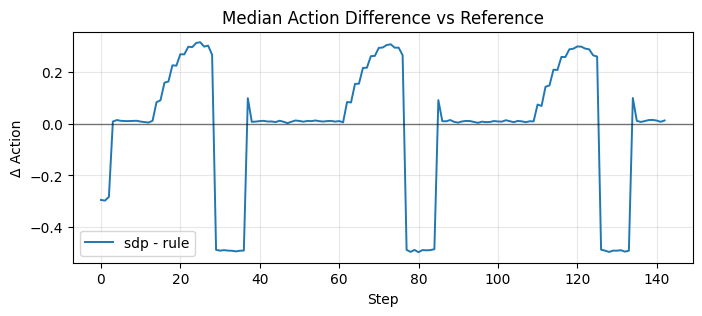

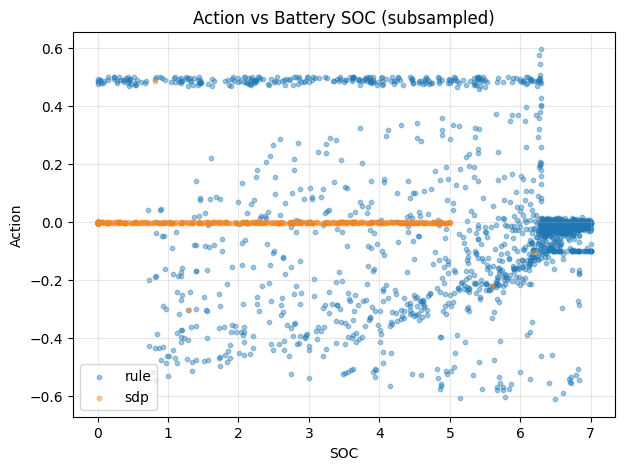

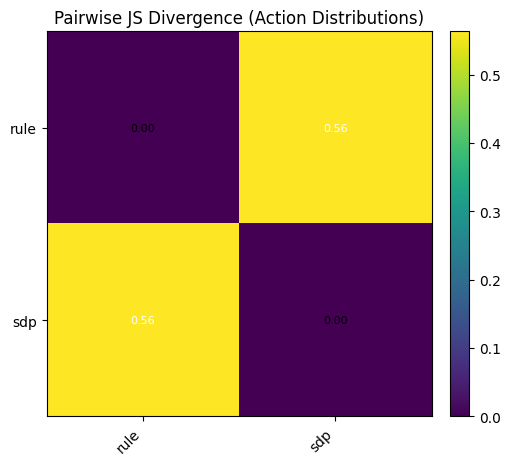

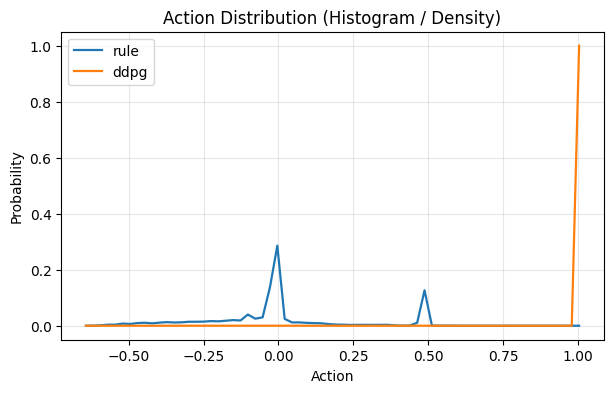

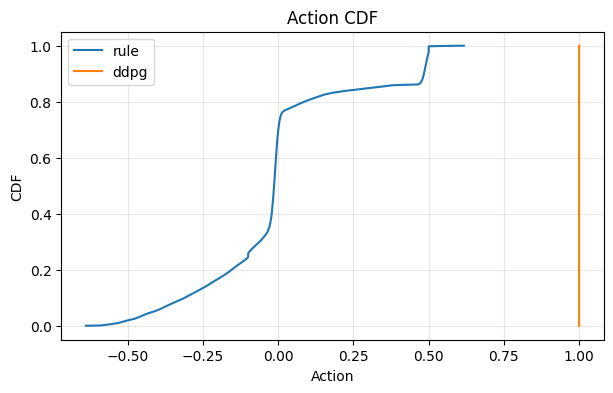

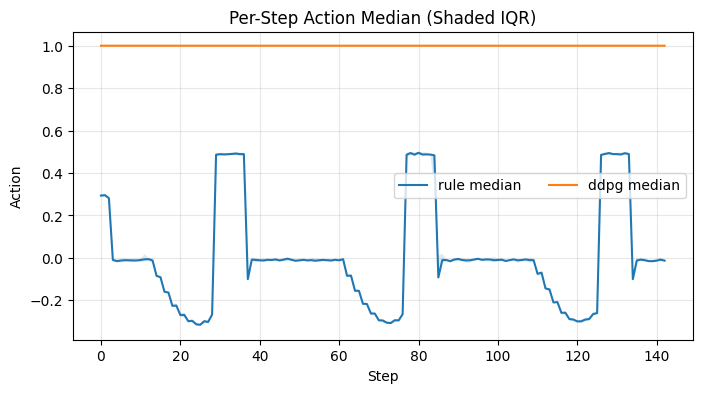

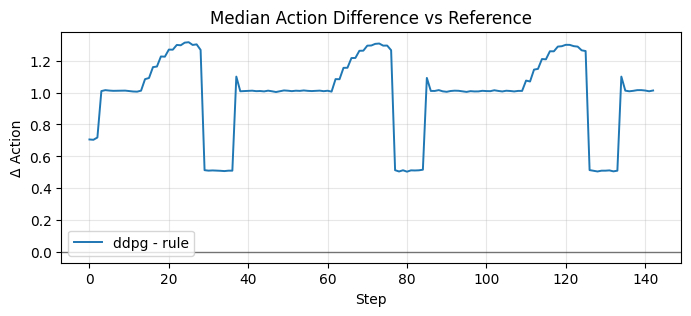

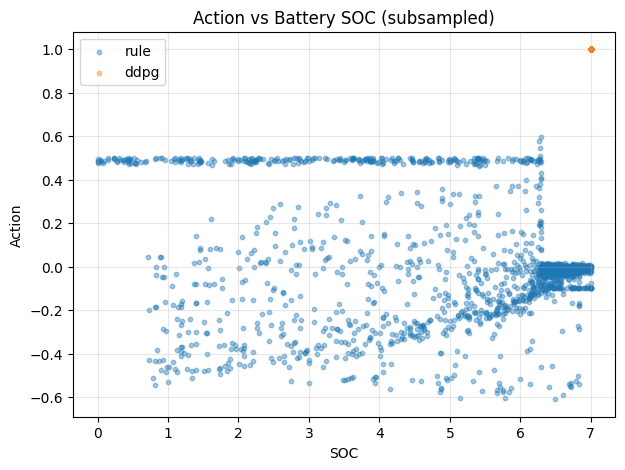

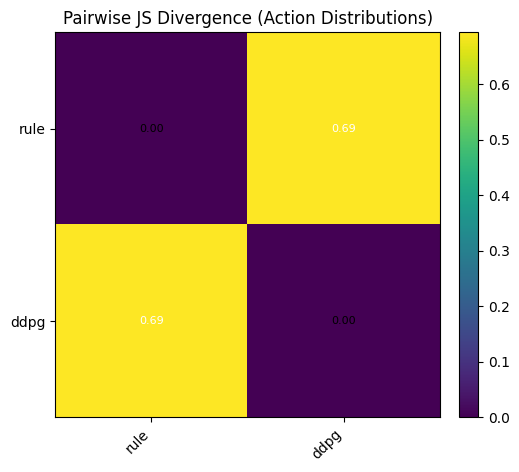

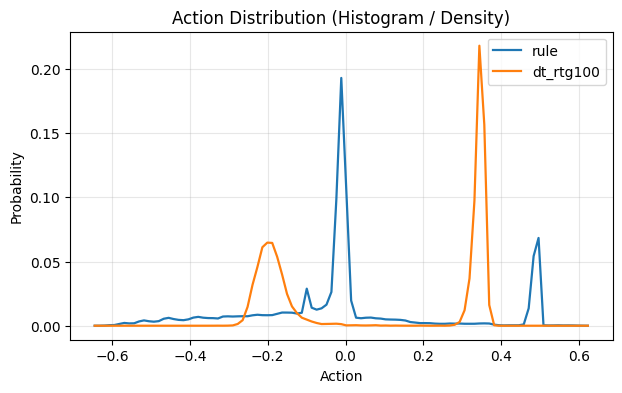

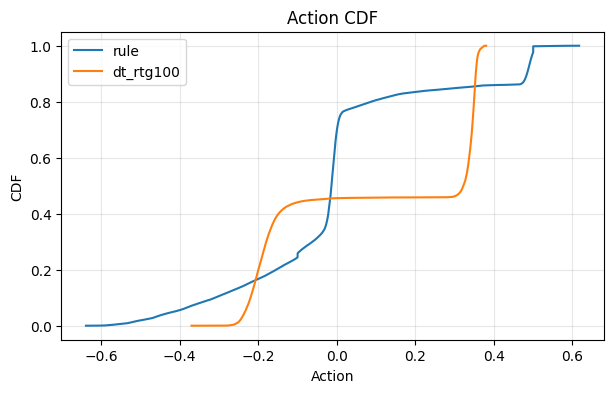

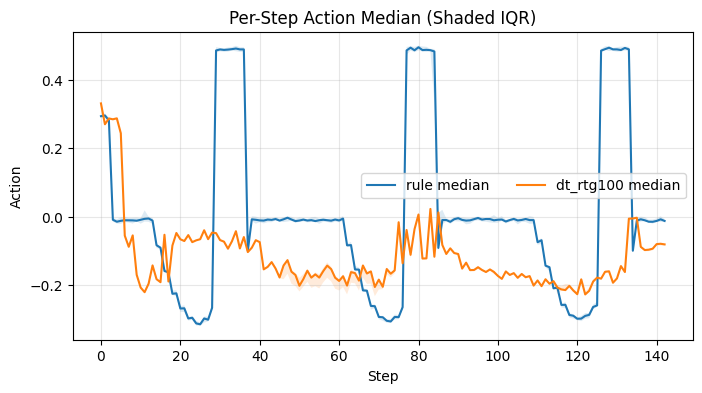

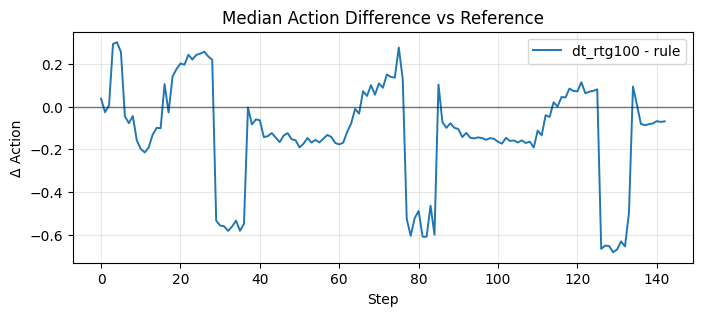

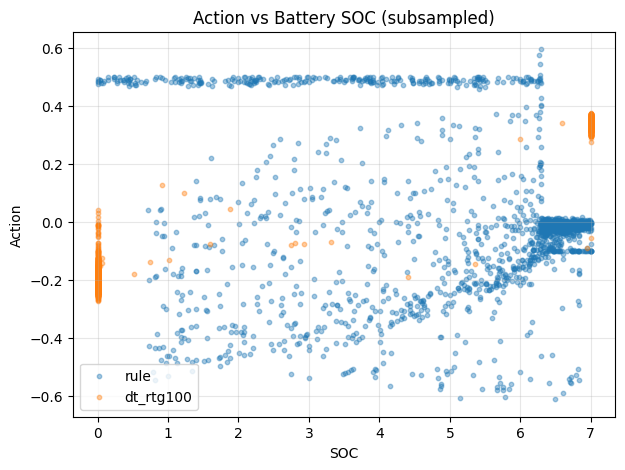

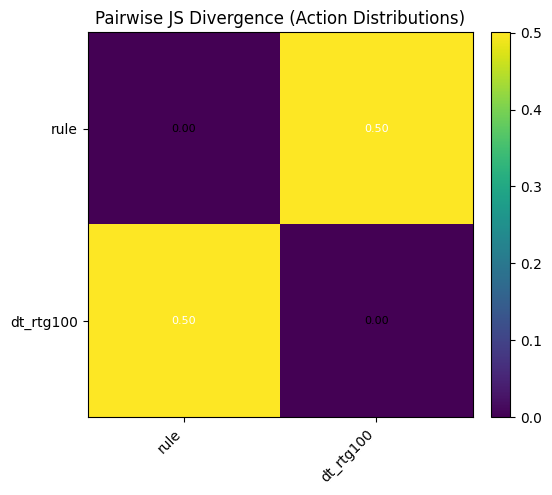

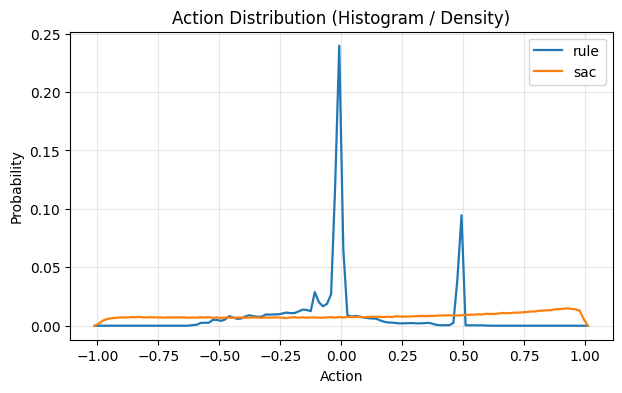

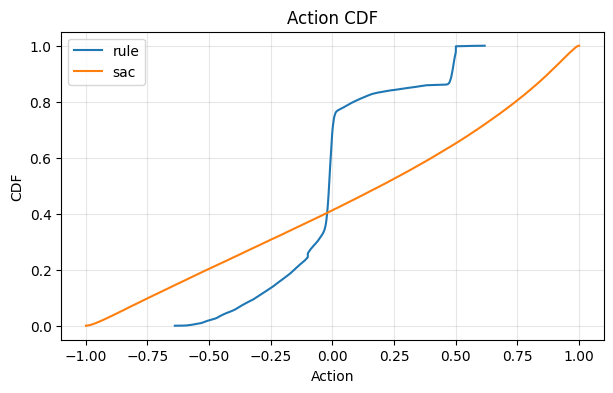

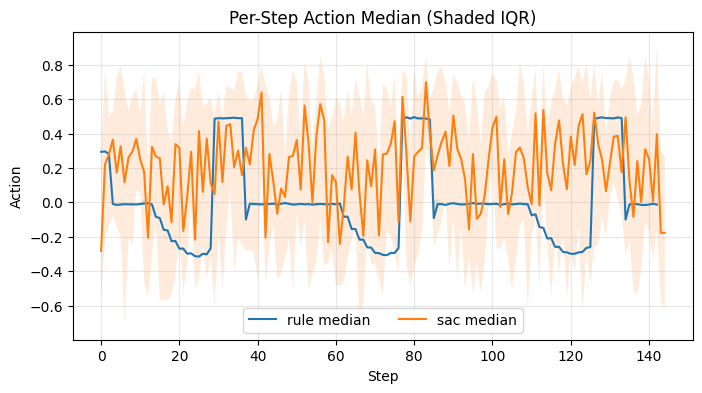

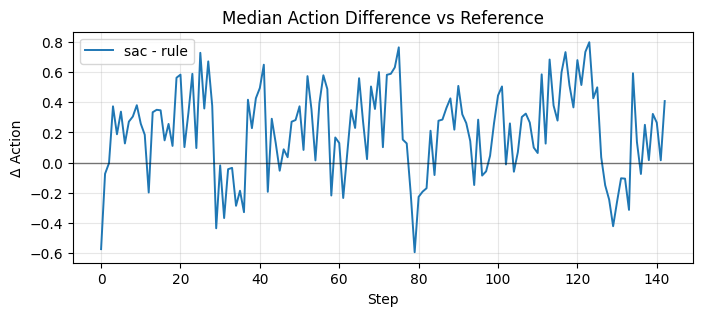

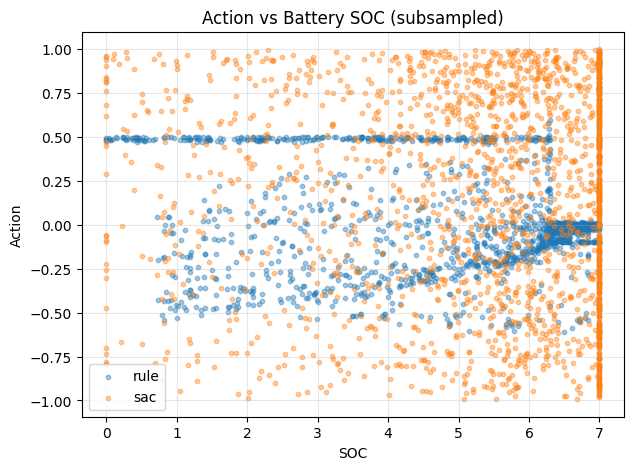

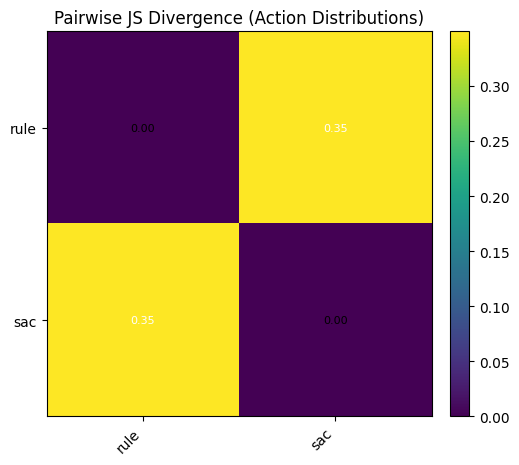

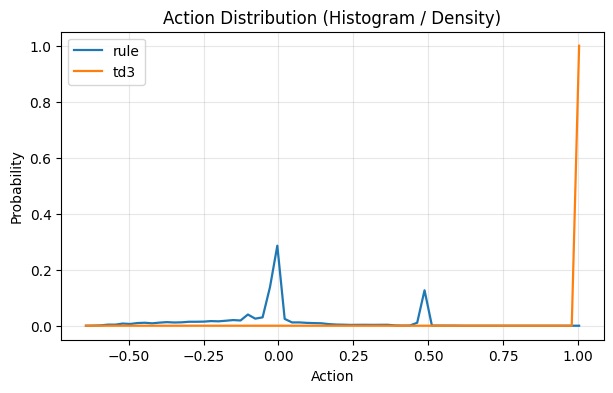

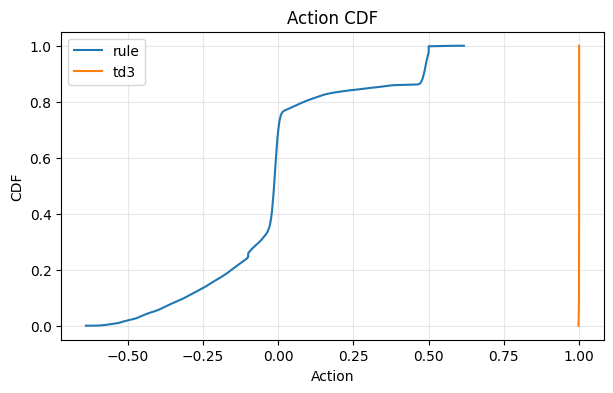

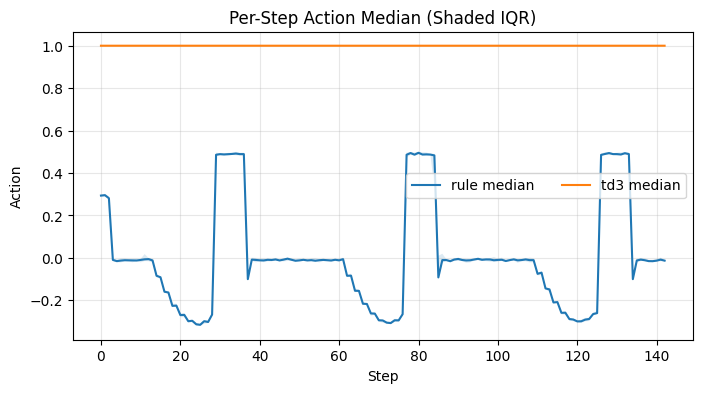

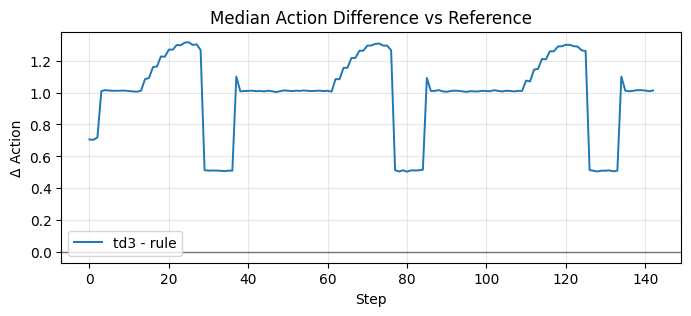

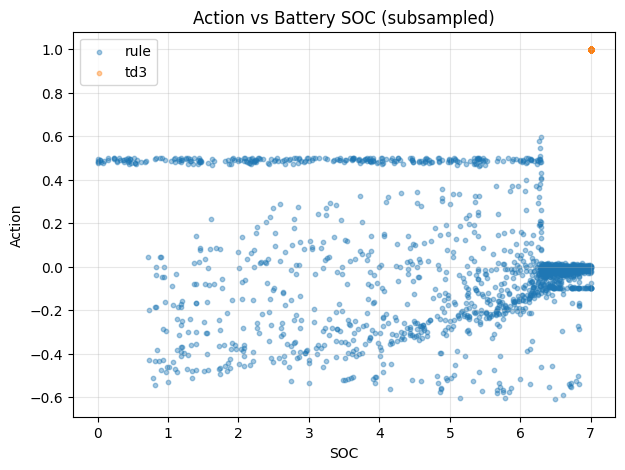

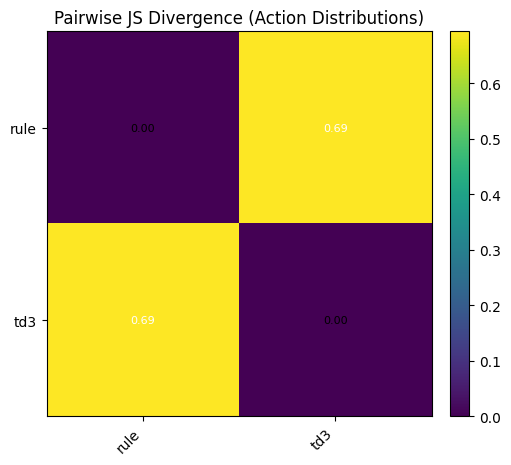

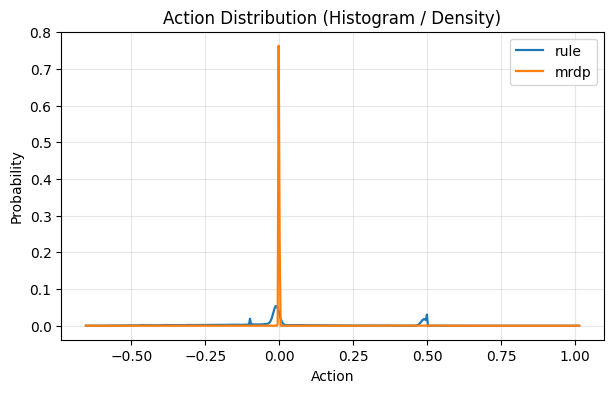

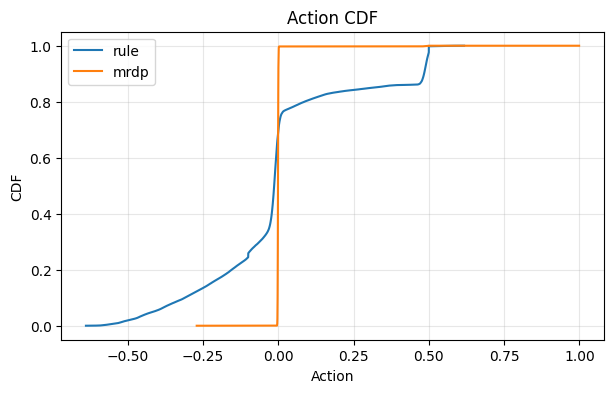

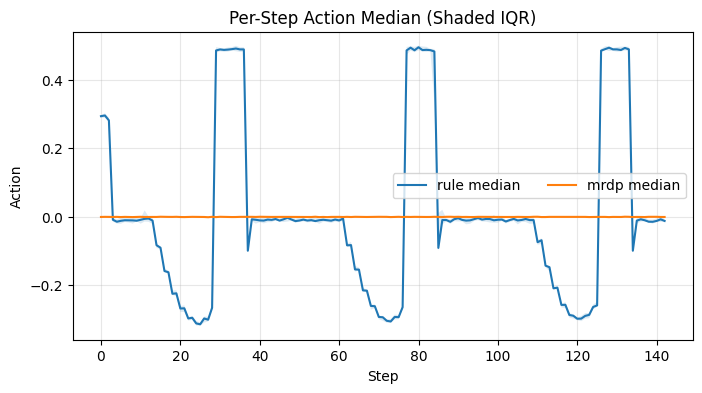

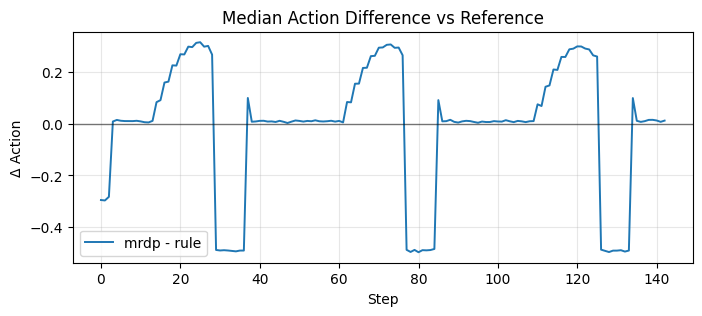

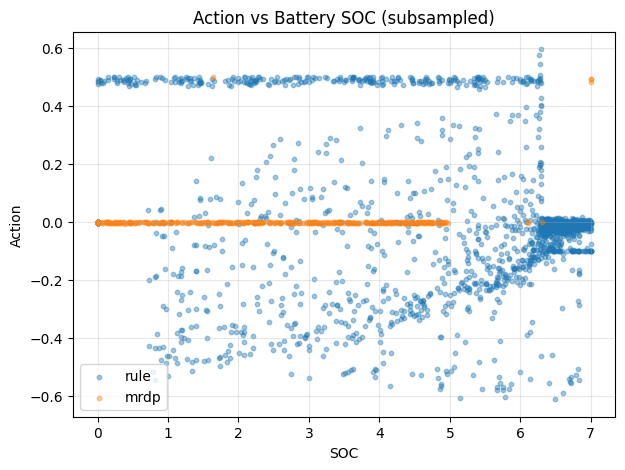

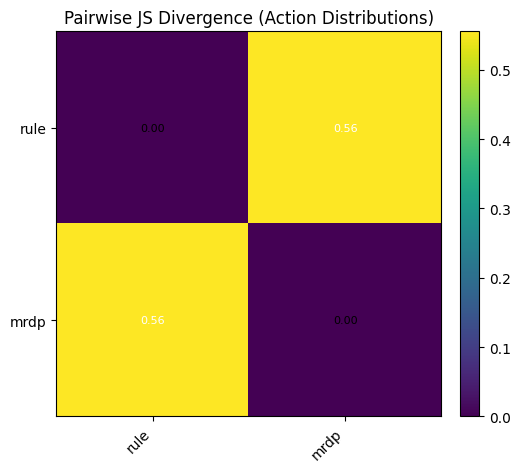

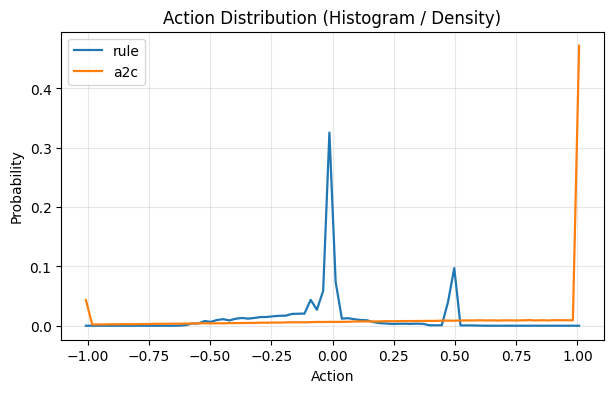

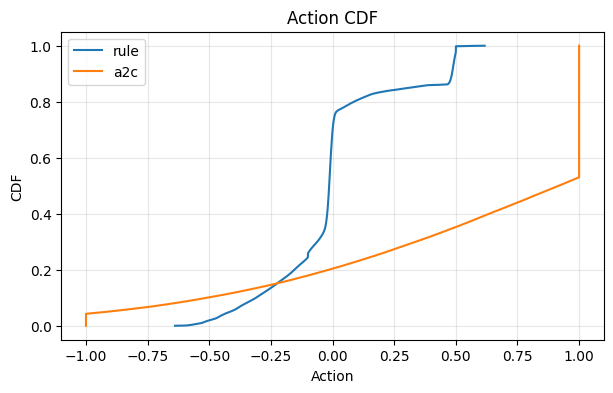

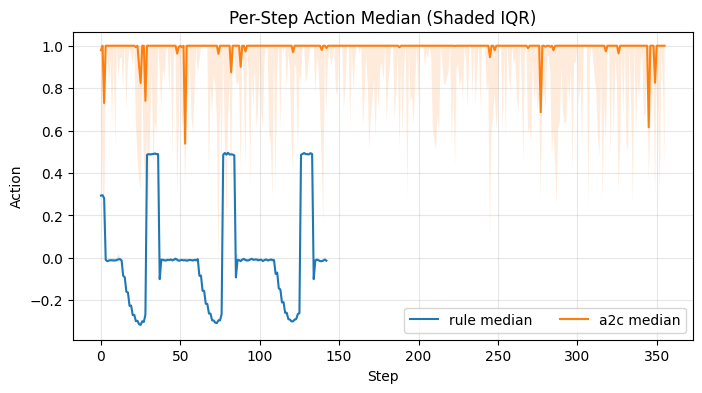

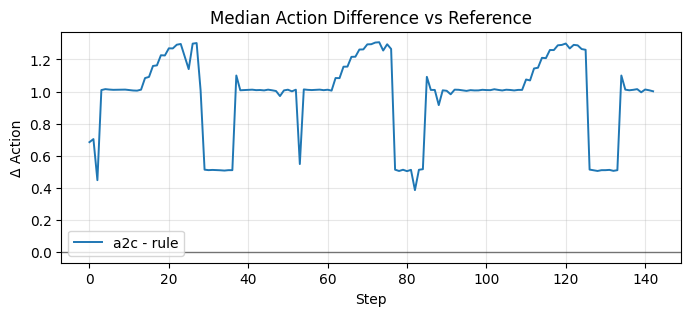

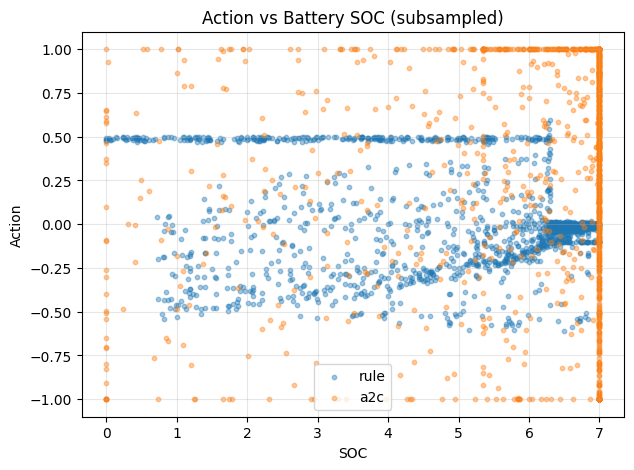

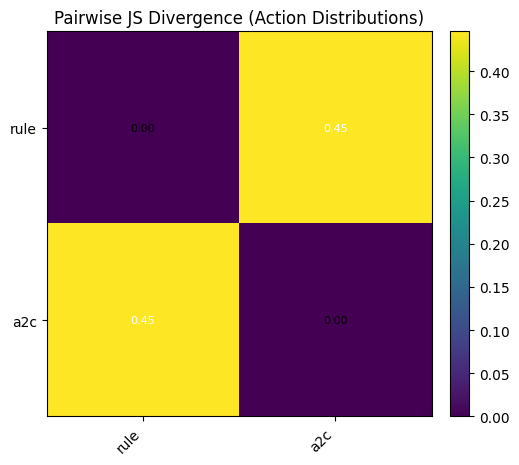

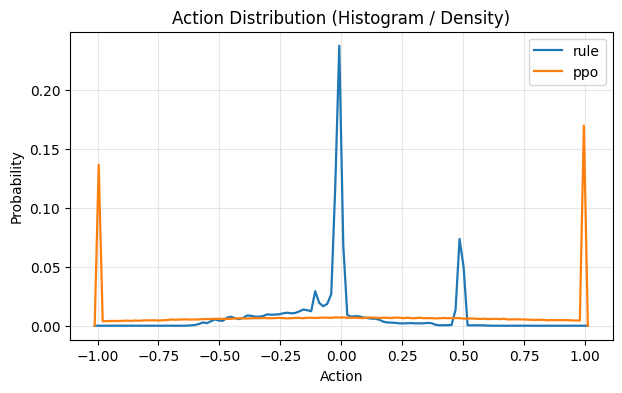

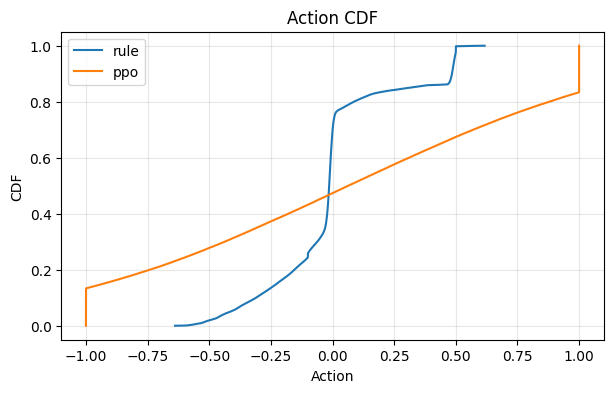

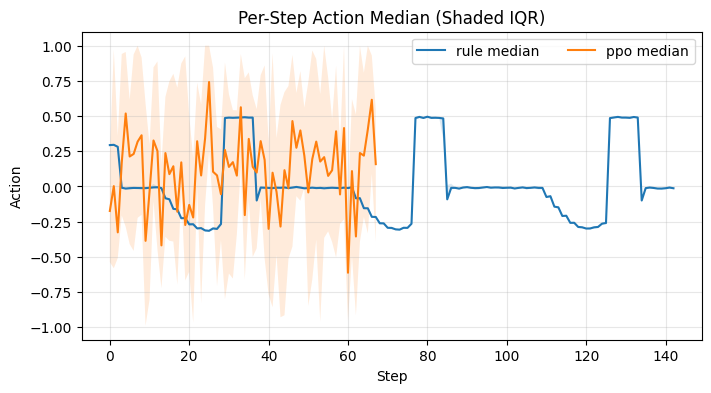

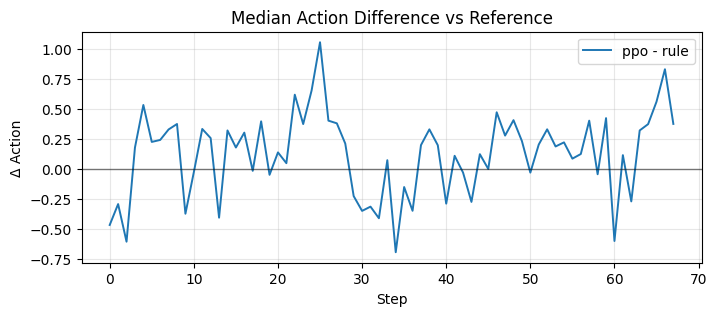

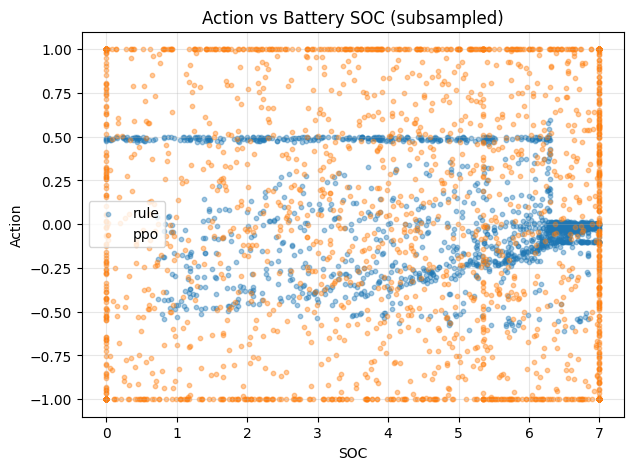

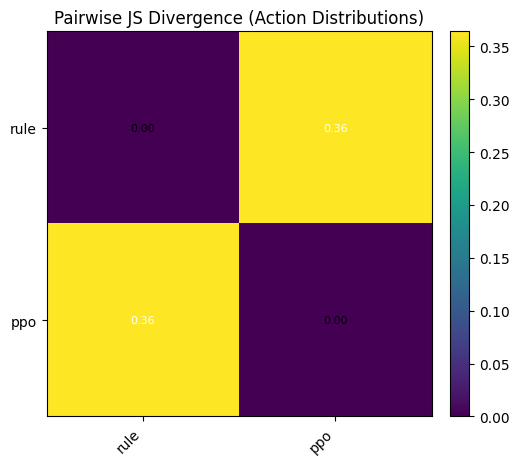

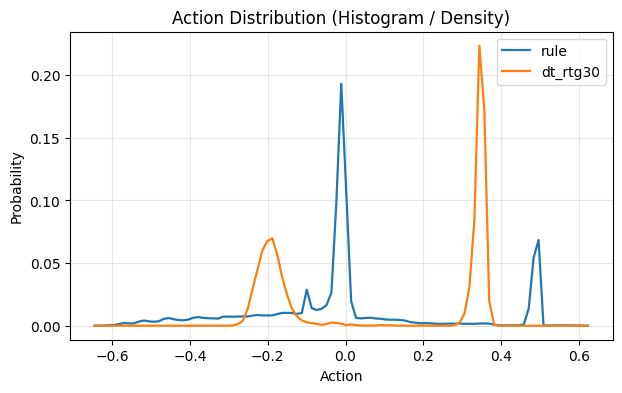

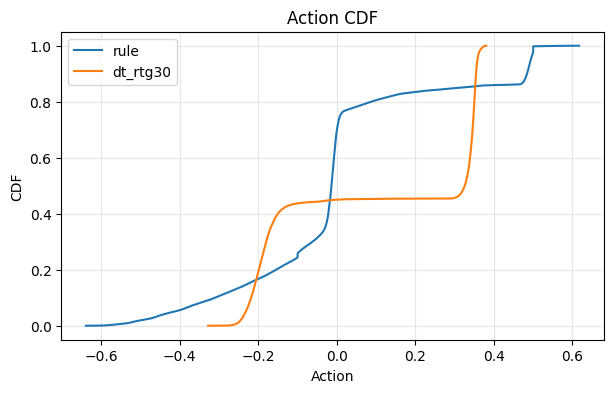

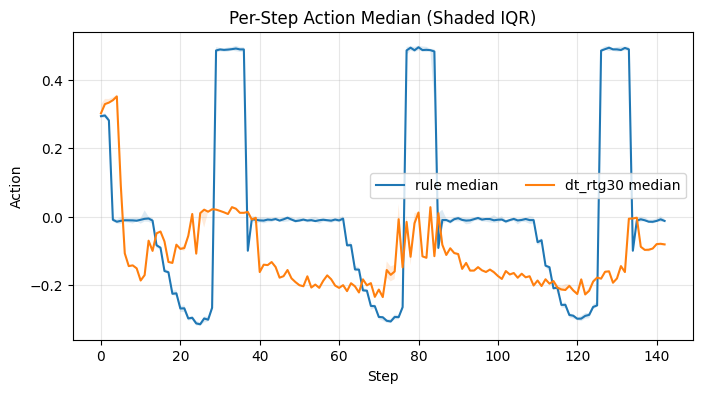

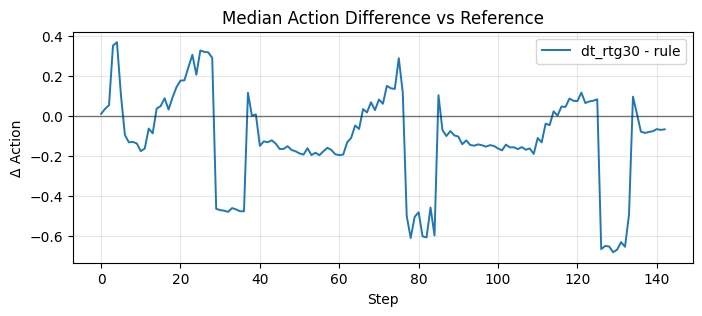

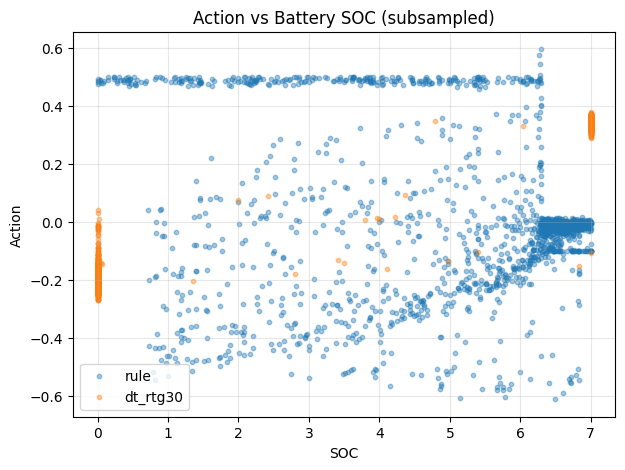

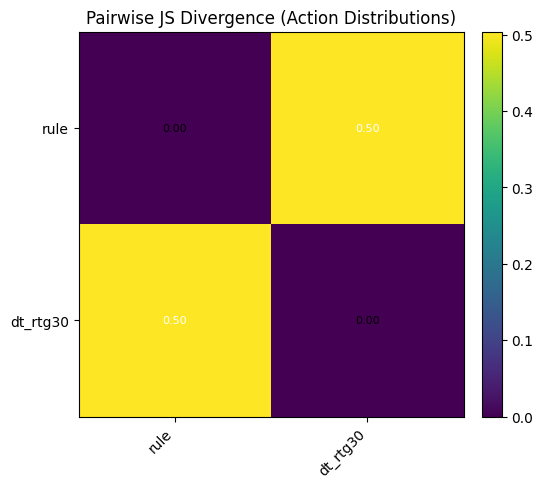

In [8]:
# overall comparison for action stat
base_save_dir = "../eval_output"
pairwise_results = compare_action_pairwise_to_reference(
    all_logs,
    reference="rule",
    base_save_dir=base_save_dir,
    time_periods=None,
    bins='auto',
    max_episodes=20 # only uses 20 episodes to compile the stat
 )

In [8]:
"""
# Example: create named time windows (start_step, end_step) you can pass to the comparator
time_periods = {
    "first_2_days": (first_step, first_step + two_day_steps),
    "4th_week_2_days": (fourth_week, fourth_week + two_day_steps),
    "4th_month_2_days": (fourth_month, fourth_month + two_day_steps),
    "11th_month_2_days": (eleventh_month, eleventh_month + two_day_steps),
    "morning": (first_step + five_am_mark, first_step + ten_am_mark),
    "afternoon": (first_step + three_pm_mark, first_step + three_pm_mark + steps_per_hour),  # 1-hour window
    "evening": (first_step + nine_pm_mark, first_step + nine_pm_mark + steps_per_hour),     # 1-hour window
}
"""

time_periods = [
    (fourth_week, fourth_week + two_day_steps/2),
]

{'per_algorithm': {'sdp': {'mean_action': -0.0011111403261262847, 'std_action': 0.0009058703643492214, 'min_action': -0.004206417128443718, 'max_action': 0.0007639306713826954}, 'ddpg': {'mean_action': 0.9999997491637865, 'std_action': 3.44333633449122e-07, 'min_action': 0.999998927116394, 'max_action': 1.0}, 'dt_rtg100': {'mean_action': -0.1845617601647973, 'std_action': 0.02678472966021075, 'min_action': -0.24415375292301178, 'max_action': -0.1319814920425415}, 'sac': {'mean_action': 0.1281408853828907, 'std_action': 0.5944341040564303, 'min_action': -0.9391122460365295, 'max_action': 0.9731298685073853}, 'td3': {'mean_action': 0.9999662563204765, 'std_action': 5.0828216322613585e-05, 'min_action': 0.9998297691345215, 'max_action': 0.9999983310699463}, 'mrdp': {'mean_action': -0.0009102823128917711, 'std_action': 0.0009426311283037162, 'min_action': -0.0030075639951974154, 'max_action': 0.0007339551812037826}, 'a2c': {'mean_action': 0.7724400175114473, 'std_action': 0.439519183861076

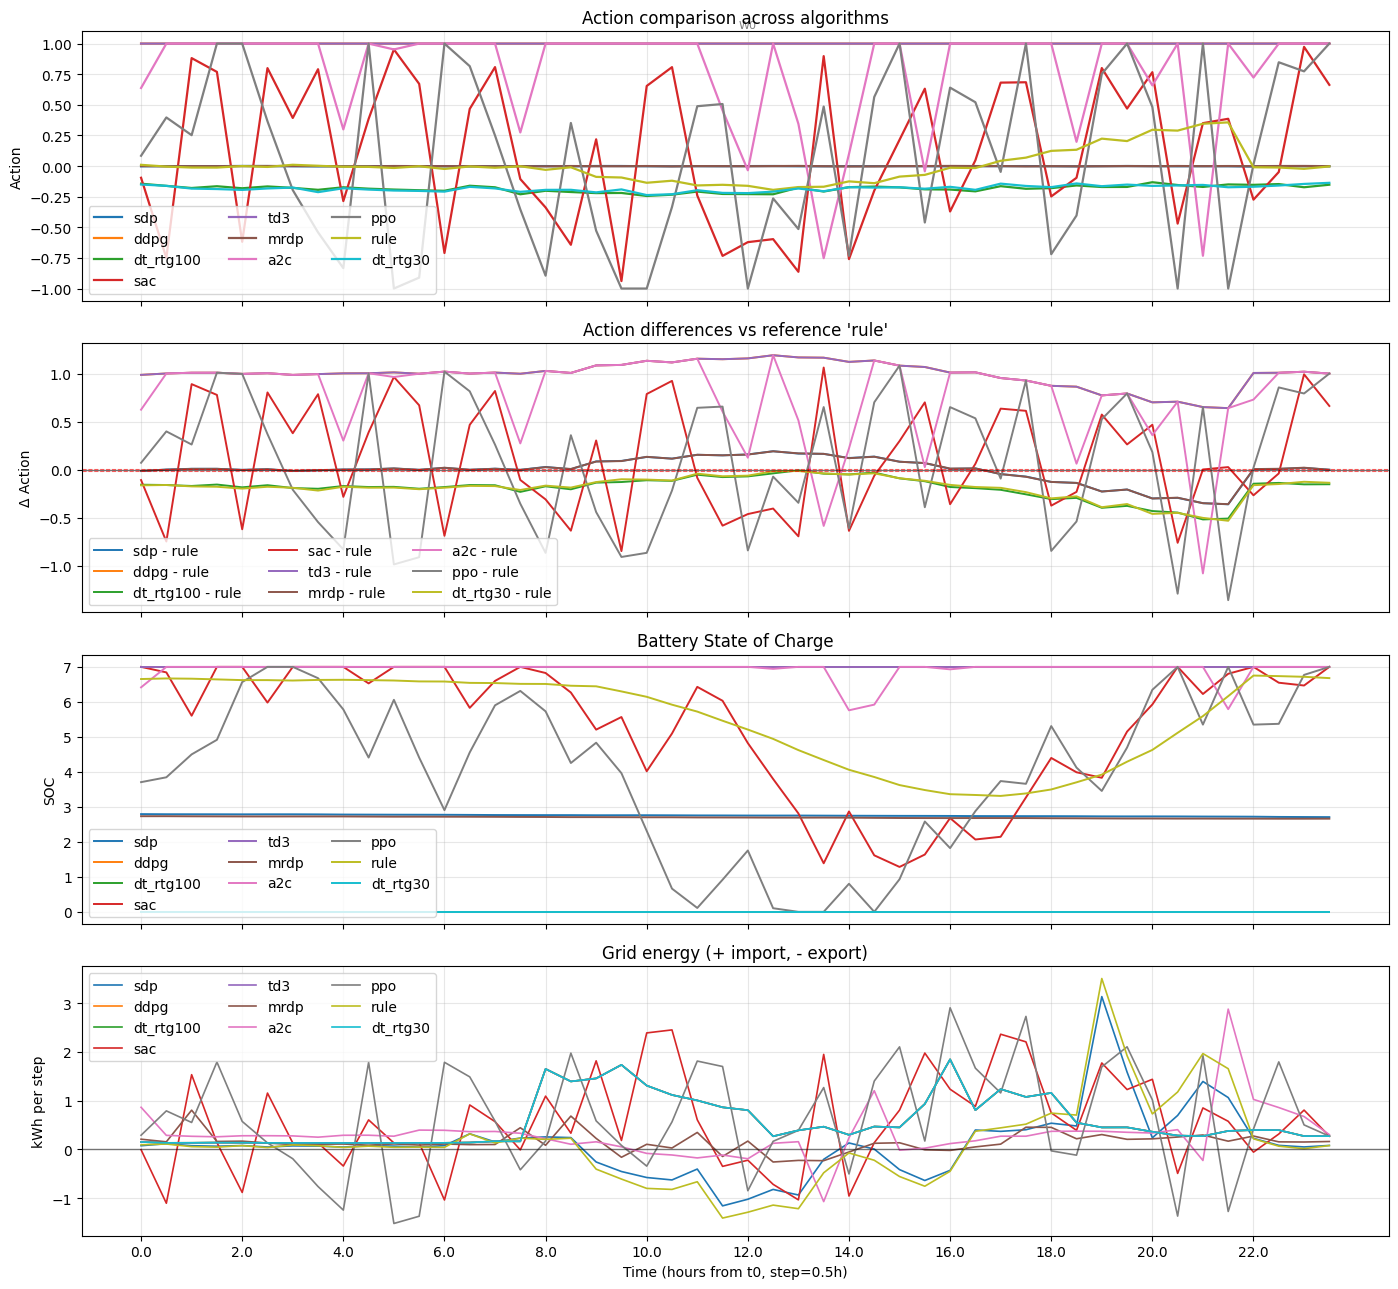

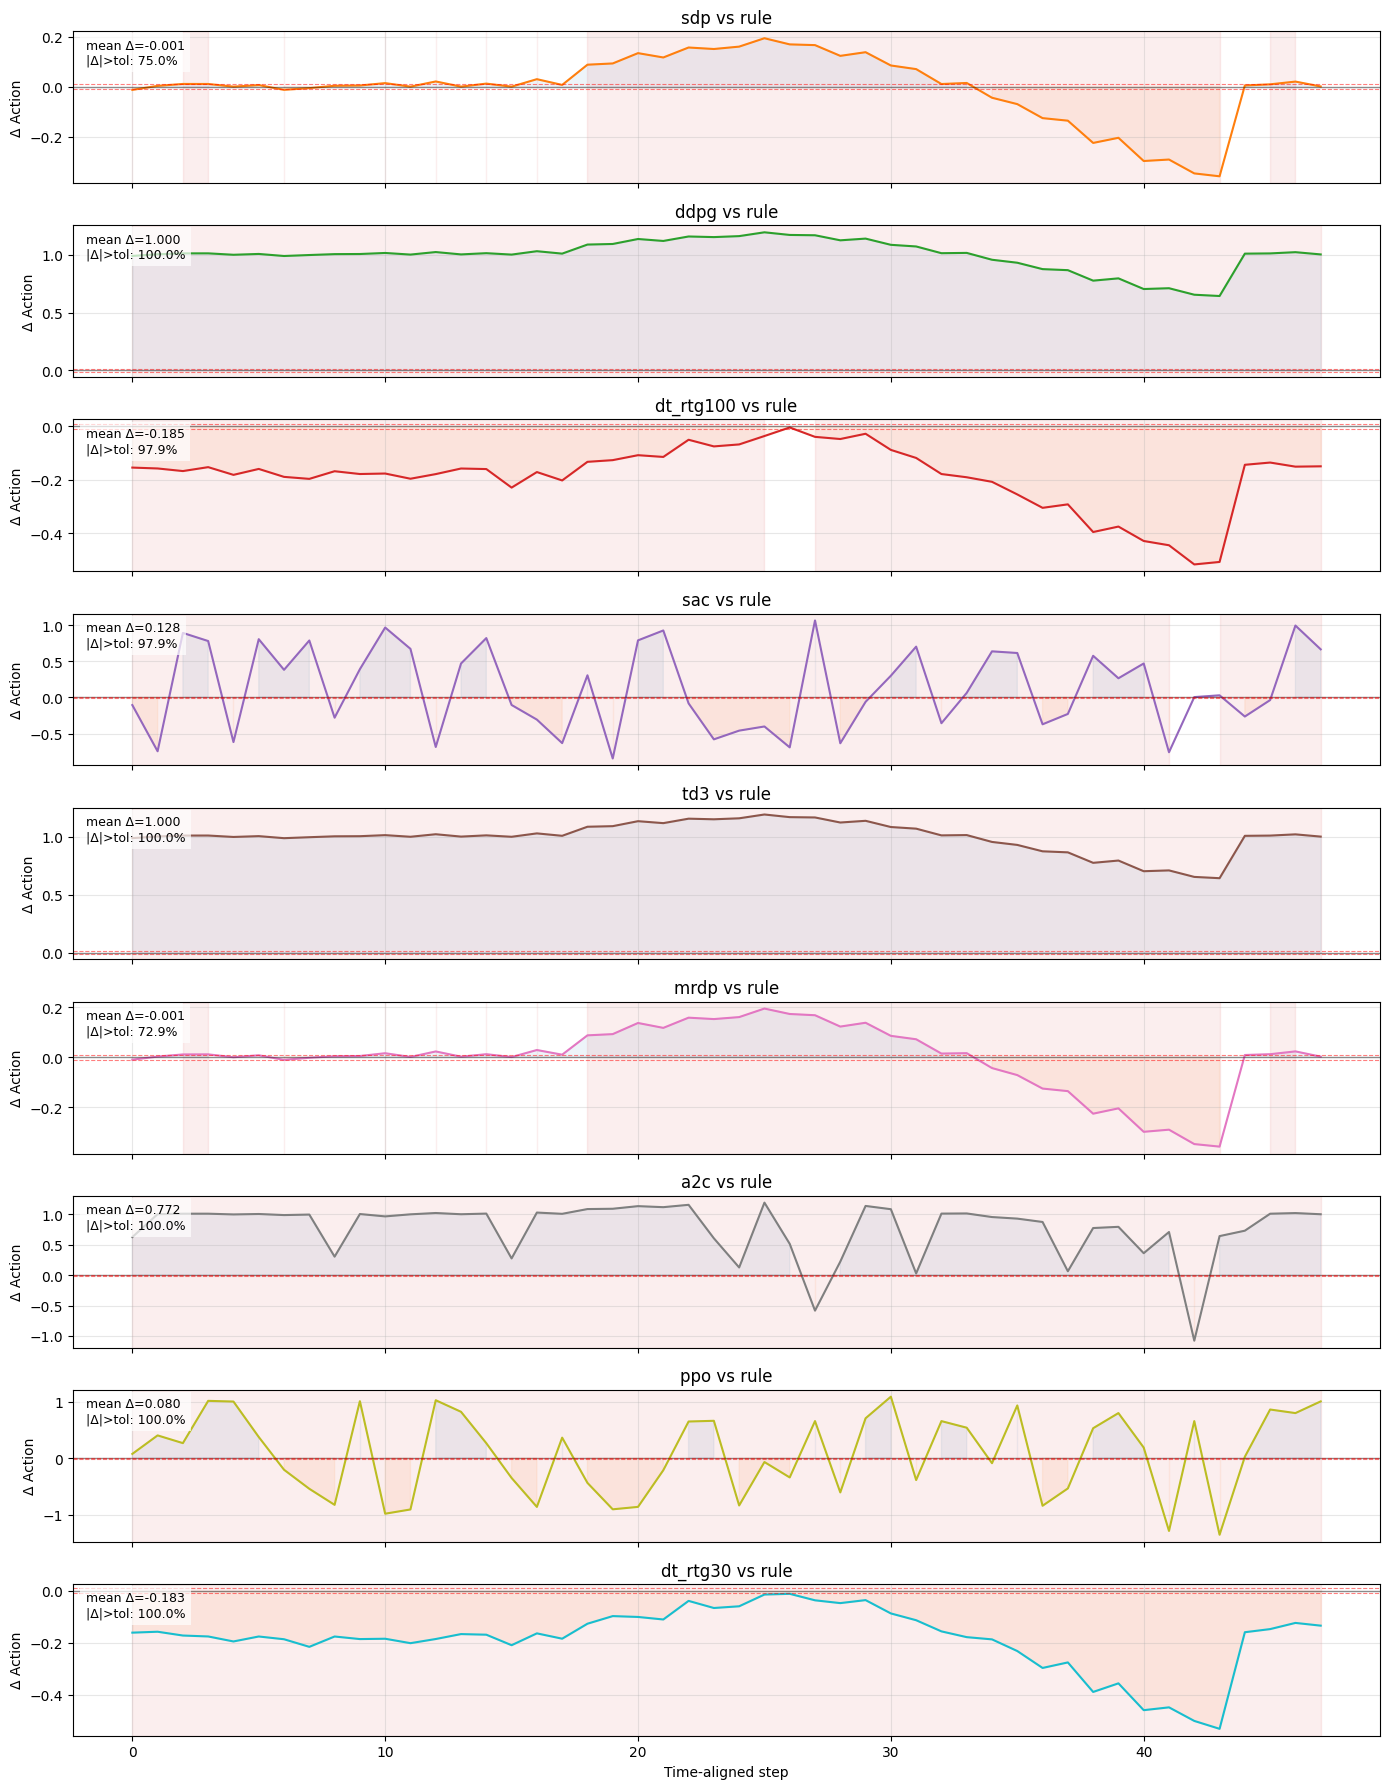

In [9]:
from helper import AlgorithmActionComparator, TemporalAnalysisConfig
import matplotlib.pyplot as plt

# Use the same time_periods defined earlier and the episode_8964 mapping (algo -> DataFrame)
# episode_8964 maps algorithm -> single episode DataFrame; analyze_temporal expects dict[str, pl.DataFrame]
base_save_dir = "../eval_output"
comparator = AlgorithmActionComparator()
# Build a unique filename for the episode and involved algos

temporal_out_path = base_save_dir + "/temporal"
cfg = TemporalAnalysisConfig(time_periods=time_periods, annotate_states=True, step_duration=0.5, reference="rule", action_tolerance=0.01, save_path=str(temporal_out_path))

result = comparator.analyze_temporal(logs_dict=episode_52, config=cfg)
fig = result.figure
stats = result.stats

# Display stats and figure
print(stats)
# In notebooks, use display of Matplotlib figure
plt.show(fig)


In [ ]:
# Example: Evaluate rewards under different conditions for one algorithm
from helper import evaluate_by_conditions

# Define your conditions (functions that take obs and return True/False)
conditions = {
    "high_solar": lambda obs: obs[5] > 2.0,
    "peak_price": lambda obs: obs[7] > 0.2,
    "low_battery": lambda obs: obs[-2] < 0.3
}

# logs is a list of Polars DataFrames for one algorithm
results = evaluate_by_conditions(logs, conditions)
print(results)